# Evaluación 1

**Integrante 1:** Maximiliano Matus

**Integrante 2:** Paz Valdes

**Integrante 3:** Santiago Franichevic

**Correo Electrónico integrante 1:** paz.valdes2301@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** maximiliano.matus2301@alumnos.ubiobio.cl

**Correo Electrónico integrante 3:** santiago.franichevic2301@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 03:24:04--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.1’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.01s   

2026-04-17 03:24:05 (234 MB/s) - ‘dataset_churn_dirty.csv.1’ saved [2771759/2771759]



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [ ]:
# Carga el set de datos
data = pd.read_csv('dataset_churn_dirty.csv')

In [ ]:
# Cantidad de observaciones y columnas
data.shape

(21000, 16)

# Revisión de nulos

In [ ]:
#Valores Faltantes y Tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

*Gracias a la info obtenida del data.info() podemos observar que dentro del total de entradas (21000) Hay varios datos que poseen un numero menor de
No nulos, lo que nos indica que en todos los datos que no tengan valor 21000, hay presencia de valores nulos*

# Revisión de atípicos

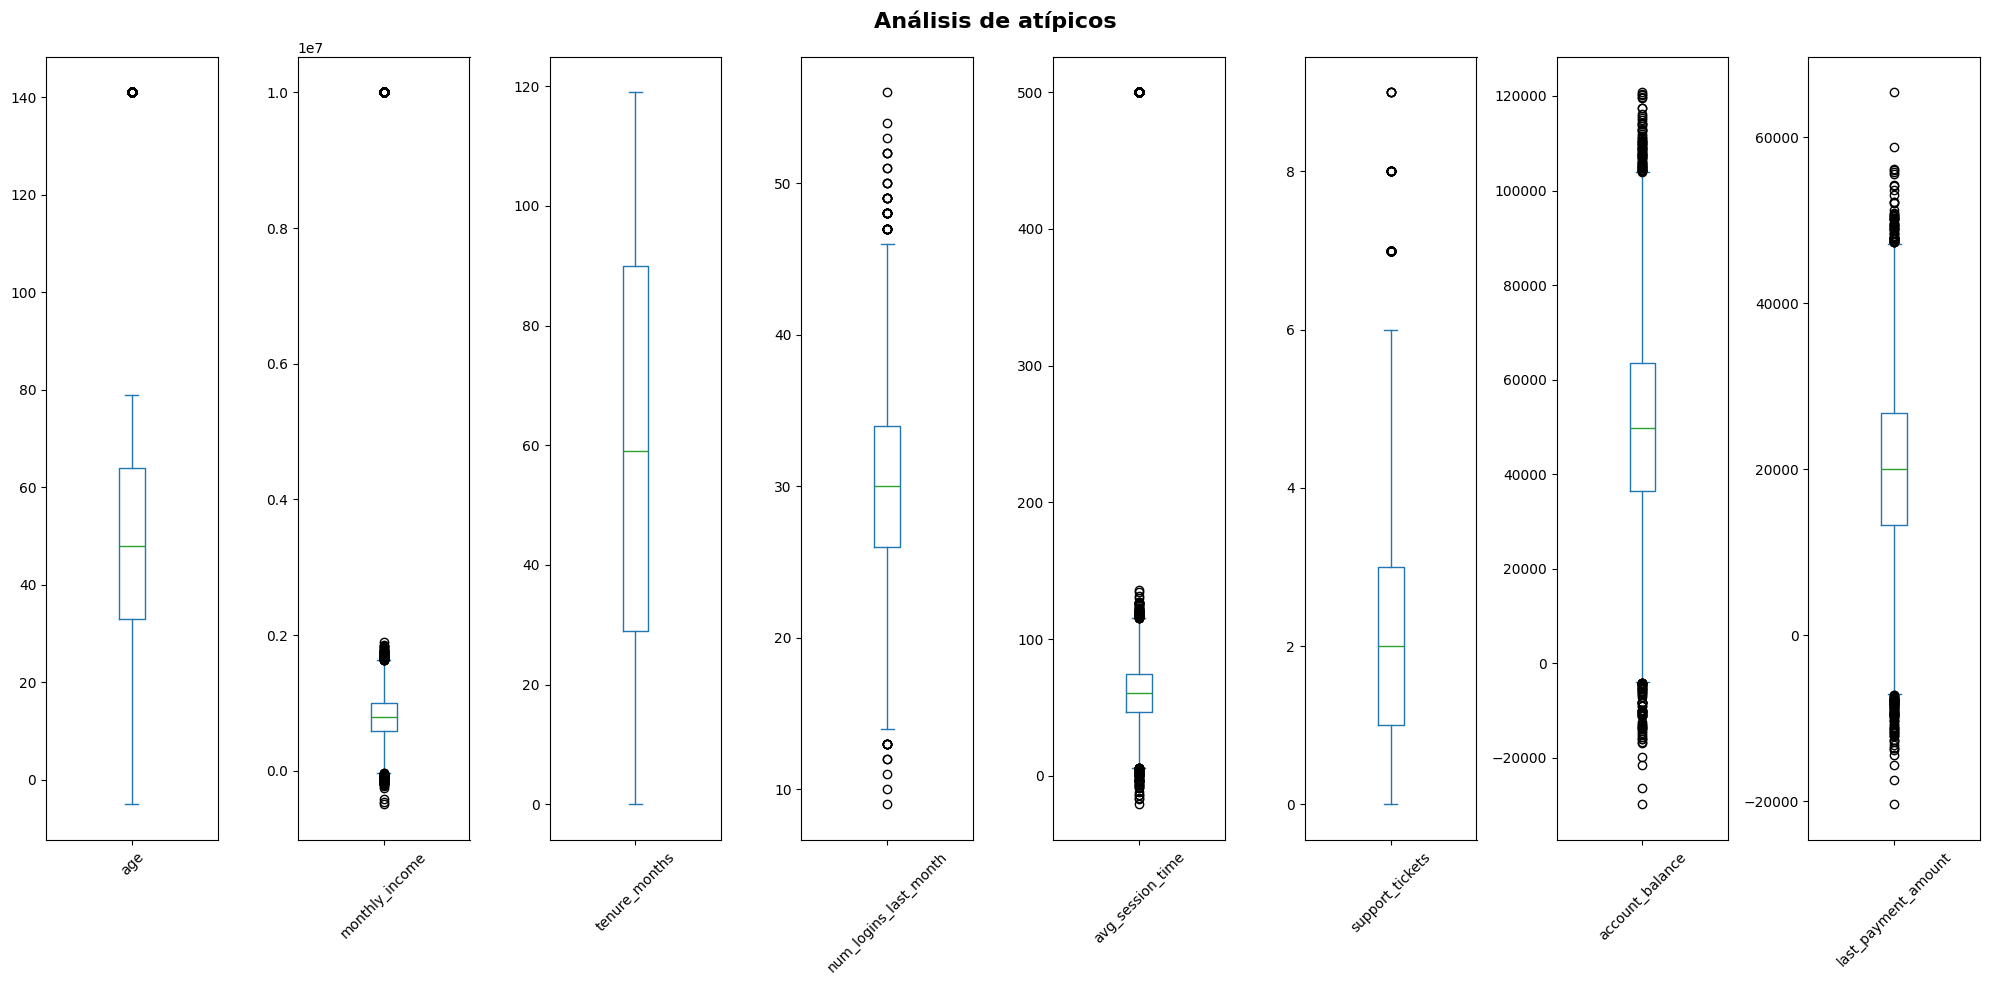

In [ ]:
# Revisión de atipicos en variables cuantitativas
revision_atipicos = ['age', 'monthly_income', 'tenure_months',
    'num_logins_last_month', 'avg_session_time',
    'support_tickets', 'account_balance', 'last_payment_amount'
]
# Codigo para realizar los boxplots con dichas variables
fig, axes = plt.subplots(1, 8, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(20,10), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

#Revisión de inconsistencias

In [ ]:
# Revisión de inconsistencias Cuantitativas

inconsistentes = data[(data["age"] <= 0) | ((data["monthly_income"] < 0) | (data["tenure_months"] < 0) | (data["num_logins_last_month"] < 0) | (data["avg_session_time"] < 0) | (data["support_tickets"] < 0)) | (data["account_balance"] < 0) | (data["last_payment_amount"] <= 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
47,48,38.0,9.393170e+05,119,28,51.699977,3,71143.120322,-8638.523066,NaN,Premium,North,Debit Card,Yes,Desktop,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
59,60,38.0,6.602348e+05,9,34,47.909770,2,71055.533036,-707.350603,Male,Enterprise,East,Debit Card,No,Tablet,0
62,63,77.0,NaN,37,25,77.341020,4,-3484.853555,19584.816007,Female,Enterprise,West,PayPal,No,Tablet,1
65,66,38.0,-1.000000e+05,81,33,55.581316,1,15548.135456,17107.203175,Other,Enterprise,North,Transfer,No,Mobile,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0
20922,7271,31.0,7.601867e+05,17,44,67.498106,1,56370.726597,-1097.518661,Female,Premium,East,Transfer,Yes,Mobile,1
20926,7888,63.0,4.528124e+05,26,45,107.170665,3,41752.594619,-1682.760110,Other,Premium,West,PayPal,Yes,Desktop,1
20927,15710,74.0,-1.000000e+05,78,39,29.099820,0,61893.441053,33285.361859,Other,Enterprise,North,PayPal,No,Mobile,0


*Como no tenemos limites superiores, las inconsistencias van a ser solo los datos que sean menores y/o iguales a cero, dependiendo del contexto*

*Con lo cual, nos da como resultado que son 1148 filas que poseen al menos un valor que tenga un resultado inconsistente dentro de la categoría Cuantitativa*

In [ ]:
# Inconsistencias cualitativas
data['gender'].unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

In [ ]:
data['subscription_type'].unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

In [ ]:
data['region'].unique()

array(['West', 'South', 'North', 'East'], dtype=object)

In [ ]:
data['payment_method'].unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

In [ ]:
data['is_active'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
data['preferred_device'].unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

In [ ]:
data['churn'].unique()

array([1, 0])

*Aqui podemos observar todas las opciones únicas dentro de cada dato cualitativo, si tuvieramos algún dato inconsistente podríamos revisarlo, pero en este caso, las unicas inconsistencias son los valores nan*

In [ ]:
# Muestra los datos cuantitativos
data.drop(columns=['customer_id','churn']).describe()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount
count,19964.000000,1.996200e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,48.763775,8.831296e+05,59.489476,29.950524,64.593725,1.999143,49991.270494,19994.073220
std,20.781103,9.800619e+05,34.825396,5.484583,48.169755,1.411416,19927.866963,10035.594111
min,-5.000000,-4.918861e+05,0.000000,9.000000,-20.873111,0.000000,-29809.544612,-20353.769010
25%,33.000000,5.904548e+05,29.000000,26.000000,46.876785,1.000000,36437.872442,13248.528218
50%,48.000000,7.989149e+05,59.000000,30.000000,60.323748,2.000000,49778.059812,19996.930030
75%,64.000000,1.007102e+06,90.000000,34.000000,74.306634,3.000000,63433.887216,26828.259187
max,141.000000,1.000000e+07,119.000000,56.000000,500.000000,9.000000,120775.517228,65425.194812


In [ ]:
#Muestra datos cualitativos
data.describe(include="object")

,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


In [ ]:
# Limitar todo lo que debe ser positivo
cols_min0 = ["monthly_income","tenure_months","num_logins_last_month","avg_session_time","support_tickets","account_balance"]
data[cols_min0] = data[cols_min0].clip(lower=0)

cols_min1 = ["age", "last_payment_amount"]
data[cols_min1] = data[cols_min1].clip(lower = 1)

In [ ]:
def feature_engineering(data: pd.DataFrame):
    """
    Realiza ingeniería de características para detectar riesgo de abandono.
    """
    # Trabajamos sobre una copia
    data = data.copy()

    # VARIABLE 1: Capacidad de pago (Financiera)
    # Si es negativo, el cliente no tiene saldo suficiente para cubrir su último pago.
    data["balance_pago_gap"] = data["account_balance"] - data["last_payment_amount"]

    # VARIABLE 2: Índice de Frustración (Comportamiento)
    # Calculamos cuántos tickets de soporte genera el cliente por cada mes de antigüedad.
    # Sumamos 1 al denominador para evitar errores de división por cero en clientes nuevos.
    data["indice_de_frustracion"] = data["support_tickets"] / (data["tenure_months"] + 1)

    return data

In [ ]:
# Se guarda un set de datos, al cual se le realizó el feature_engineering con una copia de la data original, para así mantener los datos originales
data_fe = feature_engineering(data.copy())

In [ ]:
# Revisión rápida de las nuevas columnas
print("Nuevas variables creadas:")
display(data_fe[["customer_id", "balance_pago_gap", "indice_de_frustracion"]].head())

Nuevas variables creadas:


,customer_id,balance_pago_gap,frustration_index
0,1,23533.721507,0.000000
1,2,36519.307400,0.063830
2,3,31528.220515,0.011905
3,4,-18497.735624,0.021739
4,5,43805.635700,0.030303


#Revisión de duplicados

In [ ]:
# Muestra la cantidad de datos duplicados
data.duplicated().sum()

np.int64(1000)

*Con la funcion data.duplicated().sum() nos entrega la cantidad de datos dentro de toda la data que se encuentran duplicados, el cual en este caso son 1000 datos duplicados.*

*Luego los mostramos para comprobar que efectivamente se encuentra duplicados con la variable 'customer_id'.*

In [ ]:

data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20676,54,38.0,0.000000e+00,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
53,54,38.0,0.000000e+00,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19989,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


# Limpieza y transformación

*Winsorizer trata los valores atipicos, acercandolos a los valores normales, en este caso los acerca un 5% tanto por la cota superior como inferior*

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

*Utilizamos una funcion de eliminar duplicados, para luego utilizarla directamente en el pipeline final de limpieza y transformación*

In [ ]:
def eliminar_duplicados(X : pd.DataFrame):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Set de datos.

  Retorno
  -------
  Nuevo set de datos SIN los duplicados

  """
  return X.drop_duplicates()

In [ ]:
X = data_fe.drop(columns=['churn', 'customer_id']) #Datos, en el cual se eliminan las columnas customeer_id y churn
y = data_fe['churn'] # churn es el dato que nos ayuda a predecir

In [ ]:
#definir variables cuantitativas y cualitativas
numeric_features = ["monthly_income","tenure_months","num_logins_last_month","avg_session_time","support_tickets","account_balance", "age", "last_payment_amount"]
categorical_features = ['gender', "region", "payment_method", "is_active"]

In [ ]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean")),
        ("escalado", StandardScaler())
    ]
)

In [ ]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [ ]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

In [ ]:
# Define el pipeline de limpieza y transformación
pipeline_limpieza_transformacion = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("feature_engineering", FunctionTransformer(feature_engineering)),
        ("preprocesamiento", preprocesador)
    ]
)

In [ ]:
# Se guarda los datos limpios en otra variable
X_clean = pipeline_limpieza_transformacion.fit_transform(X)

# Guarda set de datos limpio y transformado

In [ ]:
# Crea el Dataframe con los datos limpios y transformados
data_clean = pd.DataFrame(
    X_clean,
    columns=pipeline_limpieza_transformacion.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

In [ ]:
data_clean.head()

,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,age,last_payment_amount,gender_Female,gender_Male,...,region_East,region_North,region_South,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes
0,0.000000,0.478751,1.819776,-1.627287,-1.462108,1.154006,-0.533781,1.794273,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.873115,-0.395436,-0.579494,-0.534592,0.753319,0.696641,1.179584,0.669010,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.407393,0.682728,-1.379250,-0.404769,-0.723633,-0.169151,0.000000,-0.504737,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.010693,-0.424575,-1.379250,-0.291530,-0.723633,-1.503632,1.636482,1.794273,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-1.269265,1.119822,-0.179615,0.383539,0.753319,0.468662,0.208677,-0.579659,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
data_clean.shape

(20000, 21)

In [ ]:
data_clean.duplicated().sum()

np.int64(0)

In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   monthly_income              20000 non-null  float64
 1   tenure_months               20000 non-null  float64
 2   num_logins_last_month       20000 non-null  float64
 3   avg_session_time            20000 non-null  float64
 4   support_tickets             20000 non-null  float64
 5   account_balance             20000 non-null  float64
 6   age                         20000 non-null  float64
 7   last_payment_amount         20000 non-null  float64
 8   gender_Female               20000 non-null  float64
 9   gender_Male                 20000 non-null  float64
 10  gender_Other                20000 non-null  float64
 11  region_East                 20000 non-null  float64
 12  region_North                20000 non-null  float64
 13  region_South                200

### Guardar el dataset limpio

In [ ]:
data_clean.to_csv('dataset_churn_clean.csv', index=False)
print('Dataset limpio guardado como dataset_churn_clean.csv')

Dataset limpio guardado como dataset_churn_clean.csv


### Descargar el dataset limpio

In [ ]:
from google.colab import files

files.download('dataset_churn_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>